In [1]:
import numpy as np 

import torch 
from torch.utils.data import DataLoader 
from torchvision import transforms

import matplotlib.pyplot as plt

from EPOriGabors import EPGabors

In [3]:
transform = transforms.Compose(
    [
        transforms.ToTensor(), # numpy/iamges -> tensor & rescale input values to [0,1]

        # Appropriate normalization should be applied if you are working with pre-trained network.

        # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
        # transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)


img_dir = 'images/' # this should be a directory containing image files

# if you're doing binary classification of mean orientation (e.g., CW/CCW), you may want to set include_vertical=False.

# EPGabors require 'tifffile' package
batch_size = 32

gabors = EPGabors(img_dir, include_vertical=True, include_single=True, include_zerovar=True, transform=transform)
gabors_loader = DataLoader(gabors, batch_size=batch_size, shuffle=True)

images:  torch.Size([32, 3, 377, 377])
labels:  {'mean': tensor([ -4,  -8,  -4,   0,  12,  -4,   4, -12,  -4,   8,  -8,  12,   4,  12,
          0,  12,   0,   4,   4,  12,   0,  12,   0,  -4,   8,   4,   0, -12,
        -12,   8,   4,   8]), 'sd': tensor([16,  0, 16, 16,  4,  4,  0, 16,  0, 16,  4,  0,  0, 16,  4,  8, 16, 16,
        16,  8,  4,  4, 16,  4,  8,  4,  8,  8, 16, 16, 16, 16]), 'ss': tensor([32, 16,  8, 16,  4,  4,  4, 16, 16,  4,  8, 16, 16, 16,  8,  8, 16,  8,
         8,  8,  1, 32,  1,  1,  1, 32, 16, 32,  4, 16,  1, 32])}


Text(0.5, 1.0, 'mean: 4, sd: 0, ss: 16')

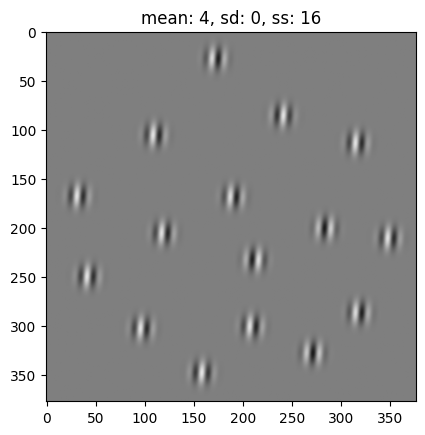

In [4]:
images, labels = next(iter(gabors_loader))

print('images: ',images.shape) # (B, C, H, W)
print('labels: ',labels) # dictionary (keys: mean, sd, ss)

this_idx = np.random.randint(low=0, high=batch_size)

plt.imshow(np.transpose(np.squeeze(images[this_idx,:,:,:]),(1,2,0)))
plt.title(f"mean: {labels['mean'][this_idx]}, sd: {labels['sd'][this_idx]}, ss: {labels['ss'][this_idx]}")